<a href="https://colab.research.google.com/github/c4u534/AutoPoET/blob/main/Morphological_Precognitive_Shape_Awareness_to_Space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Morphological image processing and embodied cognitive control share a common mathematical substrate: **Minkowski algebra over spatial lattices**. In cognitive robotics and ecological psychology (Gibson's affordance theory), an agent does not perceive an objective metric space; it perceives space through the lens of its own physical morphology, kinematic limits, and action capabilities.

Applying mathematical morphology to spatial representations (occupancy grids, depth manifolds, and sensory surfaces) operationalizes physical shape constraints as cognitive operations.

---

## Theoretical Framework

### 1. Mathematical Isomorphism: Morphological Operations and Configuration Space

Let the workspace be $\mathcal{W} \subset \mathbb{R}^d$ (typically $d \in \{2, 3\}$), partitioned into free space $\mathcal{F}$ and obstacle space $\mathcal{O}$, such that $\mathcal{F} = \mathcal{W} \setminus \mathcal{O}$.

Let the agent's physical body be represented as a compact set $\mathcal{B} \subset \mathbb{R}^d$ centered at the agent's origin $x \in \mathcal{W}$. The reflected structuring element is $\check{\mathcal{B}} = \{-b \mid b \in \mathcal{B}\}$.

The configuration space obstacle region $\mathcal{C}_{obs}$ for a purely translating agent is formally identical to the **Minkowski sum** of the obstacle space and the reflected agent geometry, which corresponds directly to **morphological dilation** ($\oplus$):

$$\mathcal{C}_{obs} = \mathcal{O} \oplus \check{\mathcal{B}} = \{ p + b \mid p \in \mathcal{O}, b \in \check{\mathcal{B}} \}$$

Conversely, the valid free configuration space $\mathcal{C}_{free}$ where the agent can exist without collision is the **morphological erosion** ($\ominus$) of the free workspace:

$$\mathcal{C}_{free} = \mathcal{F} \ominus \mathcal{B} = \{ x \in \mathcal{W} \mid \mathcal{B}_x \subseteq \mathcal{F} \}$$

Where $\mathcal{B}_x = \{b + x \mid b \in \mathcal{B}\}$.

```
  Workspace Space (W)                     Cognitive Configuration Space (C)
 ┌──────────────────────┐                ┌──────────────────────┐
 │   Obstacle O         │   Dilation     │   Inflated C_obs     │
 │    ┌───┐             │   with B       │    ┌───────┐         │
 │    └───┘             │  ─────────►    │    │       │         │
 │         Aperture     │                │    └───────┘         │
 │           ───        │                │         X Closed     │
 │    Agent B [•]       │                │    Point Agent •     │
 └──────────────────────┘                └──────────────────────┘

```

### 2. Operationalizing Ecological Affordances via Morphological Filters

Affordances represent relational properties between the environment's geometry and the agent's somatic capabilities:

* **Passability (Traversability Affordance):** An aperture $\mathcal{A} \subset \mathcal{F}$ affords passage to an agent with footprint $\mathcal{B}$ if and only if:

$$\mathcal{A} \circ \mathcal{B} = (\mathcal{A} \ominus \mathcal{B}) \oplus \mathcal{B} \neq \emptyset$$



The **morphological opening** ($\circ$) acts as an affordance filter. Sub-aperture corridors, narrow gaps, and unnavigable crevices are eliminated from the representation, leaving only regions where the agent's body can physically fit.
* **Containment and Sheltering:** The dual operation, **morphological closing** ($\bullet$), fills internal pockets and concavities smaller than the agent:

$$\mathcal{F} \bullet \mathcal{B} = (\mathcal{F} \oplus \mathcal{B}) \ominus \mathcal{B}$$



Regions closed by this operator denote spatial traps or zones where the agent cannot turn or maneuver without boundary contact.
* **Niche and Feature Identification (Hit-or-Miss Transform):** To recognize functional affordances (e.g., grasping notches, docking bays, or footholds), the hit-or-miss transform ($\circledast$) uses a composite structuring element $C = (B_{fg}, B_{bg})$:

$$\mathcal{F} \circledast C = (\mathcal{F} \ominus B_{fg}) \cap (\mathcal{F}^c \ominus B_{bg})$$



This provides an efficient, parallel method for locating spatial configurations that match specific body-environment docking configurations.

### 3. Topological Cognitive Mapping via the Medial Axis Transform

The **Medial Axis Transform** (skeletonization) of $\mathcal{C}_{free}$ generates the topological skeleton $\mathcal{S}(\mathcal{C}_{free})$:

$$\mathcal{S}(\mathcal{C}_{free}) = \bigcup_{r > 0} \left[ (\mathcal{C}_{free} \ominus r\mathcal{B}) \setminus ((\mathcal{C}_{free} \ominus r\mathcal{B}) \circ \delta\mathcal{B}) \right]$$

In cognitive control:

1. $\mathcal{S}(\mathcal{C}_{free})$ represents the Generalized Voronoi Graph (GVG), maximizing the clearance distance to all surrounding obstacles.
2. It translates continuous metric sensory fields into a discrete **topological roadmap** isomorphic to place-cell and grid-cell network graphs.
3. Trajectories routed along $\mathcal{S}(\mathcal{C}_{free})$ minimize informational entropy and homeostatic risk, functioning as default predictive paths.

---

## Architectural Taxonomy

| Image Operator | Morphological Expression | Physical Somatosensory Grounding | Cognitive Control Function |
| --- | --- | --- | --- |
| **Dilation** | $\mathcal{O} \oplus \check{\mathcal{B}}$ | Collision horizon expansion | Proprioceptive body-boundary projection |
| **Erosion** | $\mathcal{F} \ominus \mathcal{B}$ | Somatosensory shrinkage | Reachable workspace delineation |
| **Opening** | $(\mathcal{F} \ominus \mathcal{B}) \oplus \mathcal{B}$ | Elimination of tight passages | Passability affordance detection |
| **Closing** | $(\mathcal{F} \oplus \mathcal{B}) \ominus \mathcal{B}$ | Bridging sensory discontinuities | Horizon smoothing & trap detection |
| **Topological Skeleton** | $\mathcal{S}(\mathcal{F} \ominus \mathcal{B})$ | Equidistant clearance ridge | Topological map & default safe routing |
| **Hit-or-Miss** | $(\mathcal{F} \ominus B_1) \cap (\mathcal{F}^c \ominus B_2)$ | Complementary geometry matching | Grasp, dock, and step affordance detection |

---

## Interactive Visualizer: Body Constraints to C-Space

The following interactive model demonstrates how altering an agent's physical footprint size transforms the environment's topology, opening or closing apertures and reshaping the safe navigation skeleton.

---

## Python Proof-of-Concept

This self-contained implementation demonstrates:

1. Constructing arbitrary geometric body footprints (structuring elements).
2. Computing the configuration space ($\mathcal{C}_{free}$) via binary morphological operations.
3. Extracting topological roadmaps using morphological thinning / skeletonization.
4. Planning safe paths constrained by the agent's physical footprint.

Narrow Aperture Passable (Small Agent): True
Narrow Aperture Passable (Large Agent): False


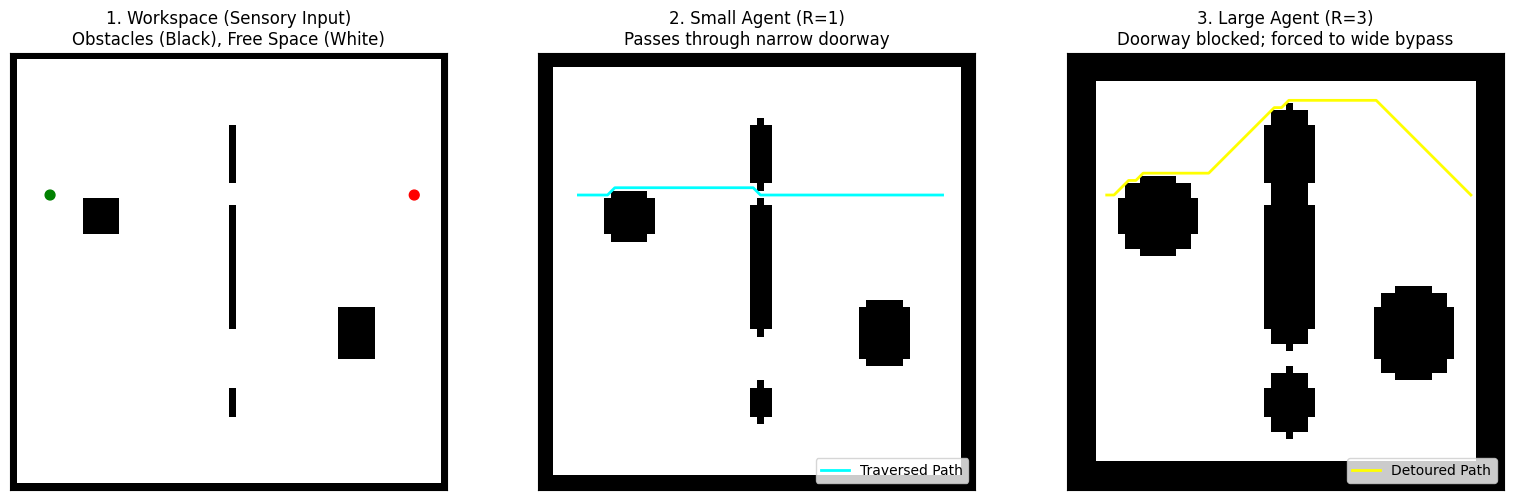

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import (
    binary_dilation,
    binary_erosion,
    binary_opening,
    distance_transform_edt,
    generate_binary_structure
)
from collections import deque


class EmbodiedAgent:
    """Represents an agent with a specific physical footprint (structuring element)."""
    def __init__(self, shape: str = "disk", radius: int = 3):
        self.radius = radius
        self.shape = shape
        self.footprint = self._generate_footprint()

    def _generate_footprint(self) -> np.ndarray:
        size = 2 * self.radius + 1
        y, x = np.ogrid[-self.radius:self.radius + 1, -self.radius:self.radius + 1]

        if self.shape == "disk":
            mask = (x**2 + y**2) <= self.radius**2
        elif self.shape == "square":
            mask = np.ones((size, size), dtype=bool)
        elif self.shape == "cross":
            mask = (x == 0) | (y == 0)
        else:
            raise ValueError(f"Unknown shape: {self.shape}")
        return mask.astype(bool)


class MorphologicalCognitiveMap:
    """
    Translates raw metric sensory grids into morphology-grounded affordance maps
    and topological navigation graphs.
    """
    def __init__(self, workspace_grid: np.ndarray, agent: EmbodiedAgent):
        # 1 = obstacle, 0 = free space
        self.raw_workspace = workspace_grid.astype(bool)
        self.agent = agent

        # Core morphological projections
        self.c_obstacles = None
        self.c_free = None
        self.affordance_passable = None
        self.skeleton = None

        self.update_projections()

    def update_projections(self):
        """Recompute cognitive projections when agent morphology or environment updates."""
        # 1. Dilation of obstacles = C-Space obstacle inflation
        self.c_obstacles = binary_dilation(self.raw_workspace, structure=self.agent.footprint)

        # 2. C_free is the complement of C_obstacles
        self.c_free = ~self.c_obstacles

        # 3. Morphological opening on free space reveals traversable apertures
        free_space = ~self.raw_workspace
        self.affordance_passable = binary_opening(free_space, structure=self.agent.footprint)

        # 4. Medial Axis Skeletonization of C_free via distance transform ridges
        self.skeleton = self._compute_medial_axis(self.c_free)

    def _compute_medial_axis(self, free_mask: np.ndarray) -> np.ndarray:
        """Calculates topological skeleton representing maximum clearance highways."""
        if not np.any(free_mask):
            return np.zeros_like(free_mask, dtype=bool)

        # Ridge detection on Euclidean Distance Transform
        dist = distance_transform_edt(free_mask)
        struct = generate_binary_structure(2, 2)

        # Local maxima of distance transform delineate the medial axis
        dilated_dist = binary_dilation(dist, structure=struct)
        # Skeleton points correspond to ridges where dilation matches original within free space
        skeleton = (dist == dilated_dist) & (dist > 1.0) & free_mask
        return skeleton

    def query_aperture_affordance(self, aperture_slice: tuple) -> bool:
        """Checks if a specified spatial aperture affords passage to the agent."""
        sub_region = self.c_free[aperture_slice]
        return bool(np.any(sub_region))

    def plan_path_bfs(self, start: tuple, goal: tuple) -> list:
        """
        Plans a path on C_free, with strong heuristic bias toward the
        medial axis skeleton (safe topological highway).
        """
        if not self.c_free[start] or not self.c_free[goal]:
            return []  # Start or goal invalid for agent's morphology

        queue = deque([(start, [start])])
        visited = {start}

        # 8-connectivity neighborhood
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1),
                     (-1, -1), (-1, 1), (1, -1), (1, 1)]

        while queue:
            (curr_r, curr_c), path = queue.popleft()

            if (curr_r, curr_c) == goal:
                return path

            # Sort neighbors: prioritize skeleton points to maximize obstacle clearance
            valid_next = []
            for dr, dc in neighbors:
                nr, nc = curr_r + dr, curr_c + dc
                if 0 <= nr < self.c_free.shape[0] and 0 <= nc < self.c_free.shape[1]:
                    if self.c_free[nr, nc] and (nr, nc) not in visited:
                        valid_next.append((nr, nc))

            # Higher priority to points on topological skeleton
            valid_next.sort(key=lambda pt: 0 if self.skeleton[pt] else 1)

            for pt in valid_next:
                visited.add(pt)
                queue.append((pt, path + [pt]))

        return []


def run_experiment():
    # 1. Construct synthetic sensory map with narrow and wide apertures
    grid_size = 60
    workspace = np.zeros((grid_size, grid_size), dtype=bool)

    # Outer boundaries
    workspace[0, :] = workspace[-1, :] = workspace[:, 0] = workspace[:, -1] = True

    # Internal barrier with two distinct apertures:
    # Wall across x = 30
    workspace[10:50, 30] = True

    # Aperture A (Narrow doorway: width 3)
    workspace[18:21, 30] = False

    # Aperture B (Wide corridor: width 8)
    workspace[38:46, 30] = False

    # Additional obstacles
    workspace[20:25, 10:15] = True
    workspace[35:42, 45:50] = True

    # 2. Instantiate two agents with different body envelopes
    small_agent = EmbodiedAgent(shape="disk", radius=1)
    large_agent = EmbodiedAgent(shape="disk", radius=3)

    # 3. Compute Cognitive Maps
    cog_map_small = MorphologicalCognitiveMap(workspace, small_agent)
    cog_map_large = MorphologicalCognitiveMap(workspace, large_agent)

    # 4. Evaluate Affordances across the narrow aperture (rows 18-21, col 30)
    narrow_slice = (slice(18, 21), slice(29, 32))
    print(f"Narrow Aperture Passable (Small Agent): {cog_map_small.query_aperture_affordance(narrow_slice)}")
    print(f"Narrow Aperture Passable (Large Agent): {cog_map_large.query_aperture_affordance(narrow_slice)}")

    # 5. Plan paths from left side to right side
    start = (19, 5)
    goal = (19, 55)

    path_small = cog_map_small.plan_path_bfs(start, goal)
    path_large = cog_map_large.plan_path_bfs(start, goal)

    # 6. Visualization
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: Raw Workspace
    axes[0].imshow(workspace, cmap="binary")
    axes[0].set_title("1. Workspace (Sensory Input)\nObstacles (Black), Free Space (White)")
    axes[0].scatter([start[1], goal[1]], [start[0], goal[0]], c=['green', 'red'], s=50, zorder=5)

    # Plot 2: Small Agent C-Space & Path
    axes[1].imshow(cog_map_small.c_free, cmap="bone")
    if path_small:
        py, px = zip(*path_small)
        axes[1].plot(px, py, color="cyan", linewidth=2, label="Traversed Path")
    axes[1].imshow(np.ma.masked_where(~cog_map_small.skeleton, cog_map_small.skeleton),
                  cmap="autumn", alpha=0.5)
    axes[1].set_title("2. Small Agent (R=1)\nPasses through narrow doorway")
    axes[1].legend(loc="lower right")

    # Plot 3: Large Agent C-Space & Path
    axes[2].imshow(cog_map_large.c_free, cmap="bone")
    if path_large:
        py, px = zip(*path_large)
        axes[2].plot(px, py, color="yellow", linewidth=2, label="Detoured Path")
    axes[2].imshow(np.ma.masked_where(~cog_map_large.skeleton, cog_map_large.skeleton),
                  cmap="autumn", alpha=0.5)
    axes[2].set_title("3. Large Agent (R=3)\nDoorway blocked; forced to wide bypass")
    axes[2].legend(loc="lower right")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_experiment()

---

## Cognitive Control Loop Integration

To interface this mathematical framework with cognitive agent architectures (such as Active Inference, Hierarchical Subsumption, or Actor-Critic Reinforcement Learning), structuring elements operate as **somatic priors**:

```
 [Sensory Ingestion: Lidar / Depth / Vision]
                     │
                     ▼
       Raw Occupancy Grid Map M
                     │
        ┌────────────┴────────────┐
        │                         │
  Erosion (⊖ B)              Dilation (⊕ B)
        │                         │
        ▼                         ▼
 Receptive Field /         C-Obstacle Field
 Affordance Filter           Hazard Layer
        │                         │
        └────────────┬────────────┘
                     │
                     ▼
        Topological Skeletonization S
           (Voronoi Medial Axis)
                     │
                     ▼
       Hierarchical Path Evaluation
     (Belief-space trajectory selection)
                     │
                     ▼
           [Motor Control / Action]

```

1. **Fast Path (Parietal-Reflexive Layer):** Direct spatial morphology computes $\mathcal{C}_{obs} = \mathcal{O} \oplus \check{\mathcal{B}}$ in grid coordinates. If the agent's projected immediate velocity vector intersects $\mathcal{C}_{obs}$, an automatic homeostatic reflex overrides deliberative planning.
2. **Deliberative Path (Prefrontal-Topological Layer):** Path generation searches solely over the graph edges induced by the medial axis $\mathcal{S}(\mathcal{C}_{free})$. This compresses a continuous 2D/3D state space into a discrete topological roadmap, ensuring real-time performance and formal safety guarantees without requiring numerical optimization at every control cycle.
3. **Active Morphological Adaptation:** In variable-geometry systems (e.g., deformable soft robots, articulated quadrupeds crouching, or drones with folding arms), the structuring element $\mathcal{B}(q)$ is parameterized by internal joint state $q$. The agent can select an action that alters $\mathcal{B}$ to restore passability affordance through an otherwise inaccessible corridor.